# Training of SW QTSA classical Model
Compatible with PyTorch 2.5.1+

### Author
- October 2022: Prepared for Workshop on Quantum Machine Learning, 13 October 2022, organised in collaboration with QWorld, QPoland, QIndia and Quantum AI Foundation. In association with IEEE Conference Trends in Quantum Computing and Emerging Business Technologies - TQCEBT 2022
- Feb 2025: Changed to PyTorch
- Feb 2025: Addition of model instances

### Aims
> *This script aims to fit time series data with a classical quantum neural network.*

### Note
> *<font color="tomato">When running this script, you are likely to obtain slightly different results each time.</font>*

In [1]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/envs/qiskit-gpu/lib/python311.zip',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/qiskit-gpu/lib/python3.11/site-packages',
 '.',
 '..']

In [2]:
import os
import numpy as np
import pylab
import math
import json
import copy
import time
from tqdm.notebook import tqdm

from IPython.display import clear_output

from utils.Window import *
# from utils.TS import *
from utils.Charts import *
from utils.Files import *
from utils.Cost import *
from utils.Metrics import *
from utils.Models import *

import matplotlib.pyplot as plt
from matplotlib import set_loglevel
set_loglevel("error")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
### Libraries used in QTSA development
import torch
from torch import nn, tensor, optim
from torch.utils.data import DataLoader, Dataset

In [4]:
### Listing control
debug = True
seed = 2022

### Software version
MAJOR = 9
MINOR = 13

### Constants
LOG_NAME = '../log_4_iter'
CASE_NAME = 'cnn'
DATA_NAME = '2_sins_sw'
DATA_PATH = f'{LOG_NAME}/data'
TRAIN_PATH = f'{LOG_NAME}/training'
ANALYSIS_PATH = f'{LOG_NAME}/analysis'
FIGURES_PATH = f'{LOG_NAME}/figures'

### Show constants
(LOG_NAME, CASE_NAME, DATA_NAME,DATA_PATH, TRAIN_PATH, ANALYSIS_PATH, FIGURES_PATH)

('../log_4_iter',
 'cnn',
 '2_sins_sw',
 '../log_4_iter/data',
 '../log_4_iter/training',
 '../log_4_iter/analysis',
 '../log_4_iter/figures')

## Utils

In [5]:
def rand_seed():
    t=time.time(); t = int((t-int(t))*10000)
    return t

## Fetch data

In [6]:
### All created files have the following codes:
DATA_ID = '2_sins_sw_t50_v20_z0_w5_s1_h1'

### Define file names

x_all_fpath = f'{DATA_PATH}/{DATA_ID}/x_all.arr'
y_all_fpath = f'{DATA_PATH}/{DATA_ID}/y_all.arr'

x_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_train_ts.arr'
y_train_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_train_ts.arr'
x_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/x_valid_ts.arr'
y_valid_ts_fpath = f'{DATA_PATH}/{DATA_ID}/y_valid_ts.arr'

data_info_fpath = f'{DATA_PATH}/{DATA_ID}/info.json'
data_info_fpath

'../log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json'

In [7]:
### Load the info file
data_info = read_json_file(data_info_fpath)
    
### Get info details
DATA_NAME = data_info['data_name']
DATA_MAJOR = data_info['major_version'] 
DATA_MINOR = data_info['minor_version']
samples_train = data_info['data_train']
samples_valid = data_info['data_valid']
noise = data_info['data_noise']
wind_size = data_info['wind_size']
wind_step = data_info['wind_step']
horizon = data_info['wind_horizon']
seed = data_info['seed']
samples = samples_train + samples_valid
train_pc = samples_train / samples

print(f'\nSaved time series info in file "{data_info_fpath}":\n')
for k in data_info.keys():
    print(f'\tinfo[{k}] = {data_info[k]}')
print()
print(f'\tcalc[samples] = {samples}')
print(f'\tcalc[train_pc] = {train_pc}')
print()


Saved time series info in file "../log_4_iter/data/2_sins_sw_t50_v20_z0_w5_s1_h1/info.json":

	info[data_name] = 2_sins_sw
	info[major_version] = 9
	info[minor_version] = 0
	info[data_train] = 50
	info[data_valid] = 20
	info[data_noise] = 0
	info[wind_size] = 5
	info[wind_step] = 1
	info[wind_horizon] = 1
	info[seed] = 2022

	calc[samples] = 70
	calc[train_pc] = 0.7142857142857143



In [8]:
### Load data files
X_all = read_ts_file(x_all_fpath)[..., None]
y_all = read_ts_file(y_all_fpath)
X_train_ts = read_ts_file(x_train_ts_fpath)
y_train_ts = read_ts_file(y_train_ts_fpath)[..., None]
X_valid_ts = read_ts_file(x_valid_ts_fpath)
y_valid_ts = read_ts_file(y_valid_ts_fpath)[..., None]
print(f'\nLoaded time series data\n')


Loaded time series data



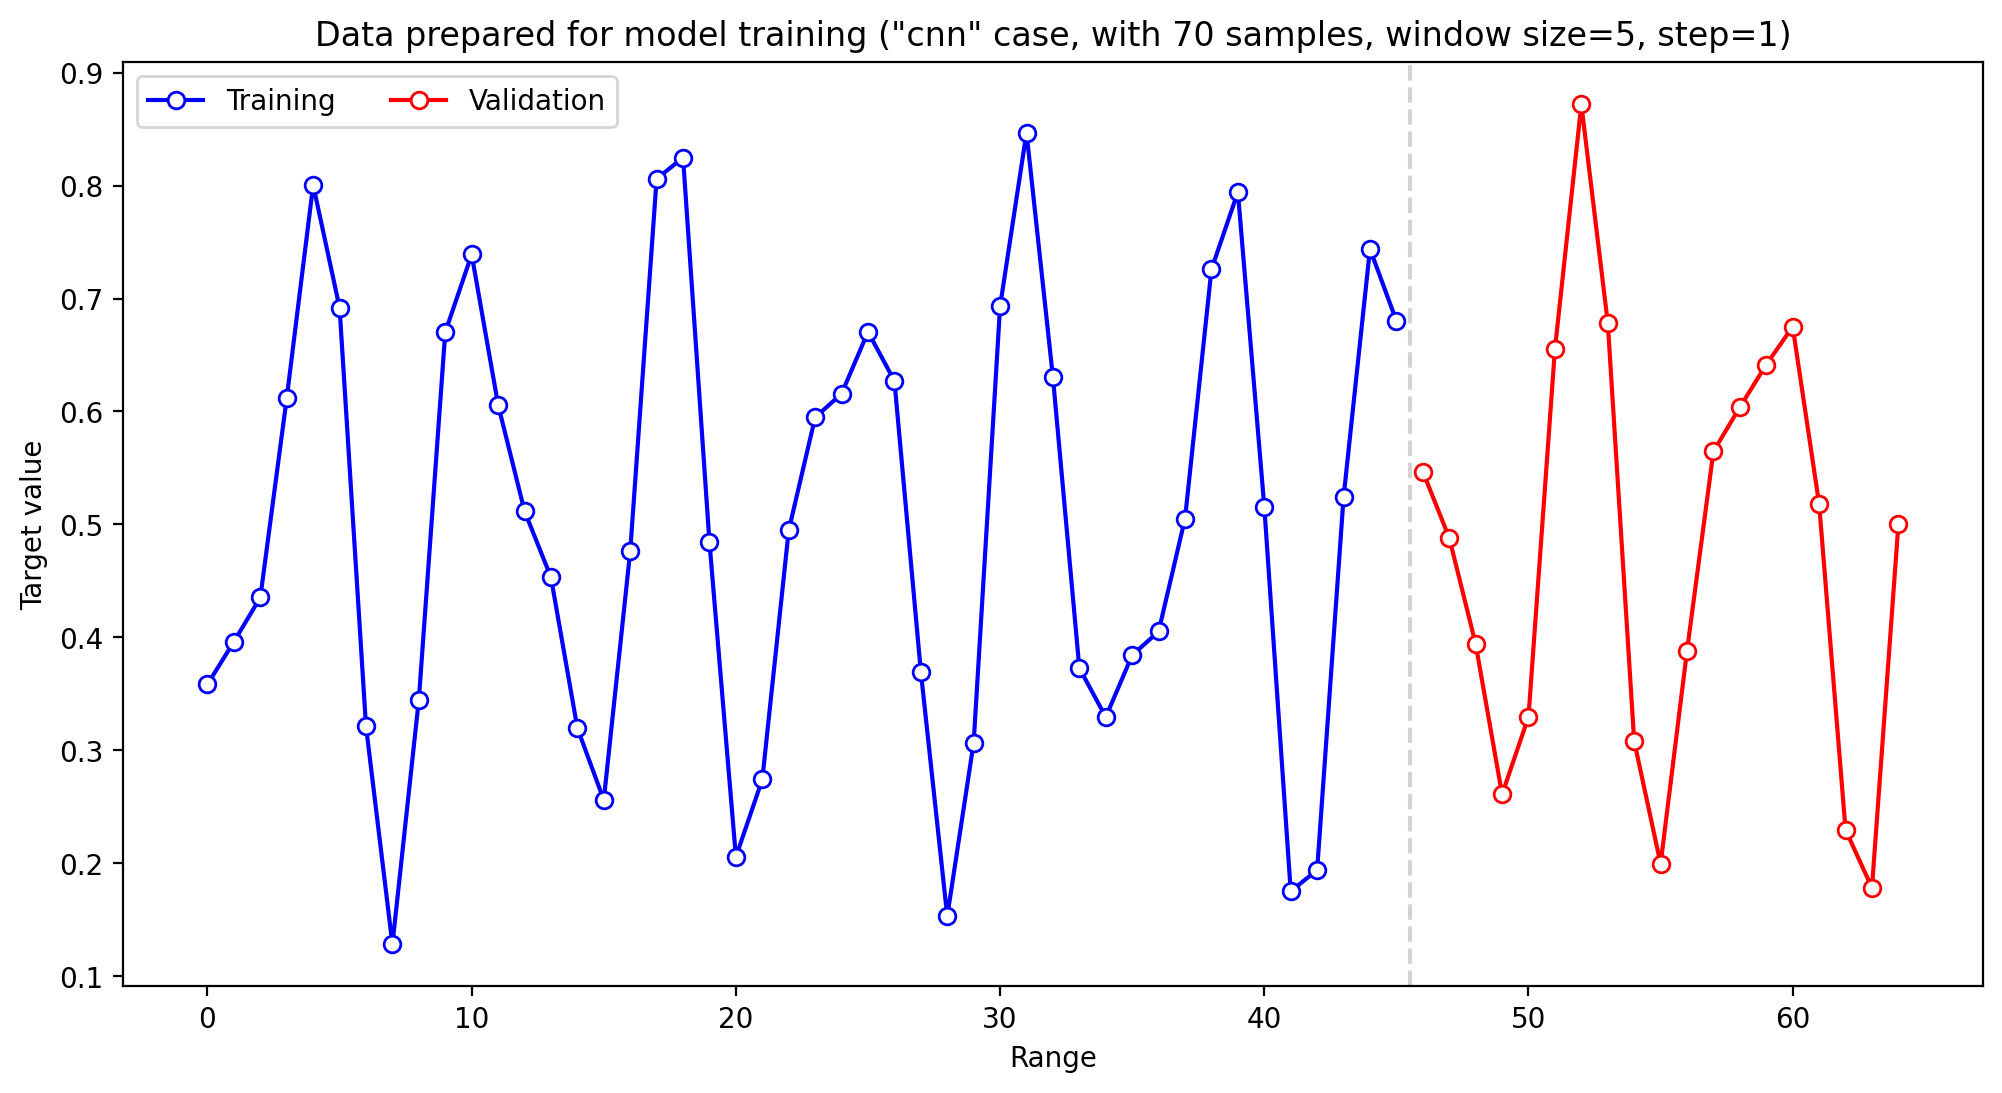

In [9]:
### Plot trainig and validation/test data partitions
#   Note that we will not use the X coordinates

y_train_flat_ts = ts_wind_flatten_avg(y_train_ts, wind_step)
y_valid_flat_ts = ts_wind_flatten_avg(y_valid_ts, wind_step)
y_list = [y_train_flat_ts, y_valid_flat_ts]
X_list = [0, len(y_train_flat_ts)]

print()
multi_plot_flat_ts(y_list, X_list=X_list, 
    colors = ['blue', 'red'], marker_colors=['white', 'white', 'lightblue', 'mistyrose'],
    labels = ['Training', 'Validation'], #ylim=(0.1, 1),
    lines = ['solid', 'solid'], markers = ['o', 'o'], legend_cols=2,
    rcParams=(12, 6), dpi=200, 
    title=f'Data prepared for model training ("{CASE_NAME}" case, '+
          f'with {samples} samples, window size={wind_size}, step={wind_step})')
print()

## Utilities

In [10]:
### Counts the number of pytorch model parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Gets all pytorch parameters
def get_param_vals(model):
    params = []
    for param in model.parameters():
        params.append(param.view(-1))
    params = torch.cat(params)
    params = params.cpu().detach().flatten() # [0]
    return params.numpy()

### Find sizes of all Linear layers
def model_layer_sizes(model):
    out_lay_sizes = []
    for name, layer in model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            out_lay_sizes.append(layer.out_features)
    in_lay_sizes = []
    for name, layer in model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            in_lay_sizes.append(layer.in_features)
    in_lay_sizes[0]
    return in_lay_sizes[0], out_lay_sizes[:-1], out_lay_sizes[-1]

## Defining PyTorch device

In [11]:
# Type to be used with tensors
dtype = torch.float32 # torch.float64
torch.set_default_dtype(dtype)

# Enable CUDA device if available
device = torch.device("cuda:0" if torch.cuda. is_available() else "cpu")
# device = "cpu"
print(f'Torch device to be used:  {device}, dtype={dtype}\n')

Torch device to be used:  cuda:0, dtype=torch.float32



## Preparing data for PyTorch

In [12]:
# Convert to PyTorch tensors
X_train_tens = torch.tensor(X_train_ts, dtype=dtype).to(device)
y_train_tens = torch.tensor(y_train_ts, dtype=dtype).to(device)
X_valid_tens = torch.tensor(X_valid_ts, dtype=dtype).to(device)
y_valid_tens = torch.tensor(y_valid_ts, dtype=dtype).to(device)

## Train classical MLP (PyTorch)

In [13]:
### PyTorch trainnig loop
def train_model(model, lossfun, optimizer, X, Y, epochs=50, log_interv=100, prompt_fract=0.1, info_level=1):

    history = []
    min_epoch = 0
    min_loss = np.inf
    opt_params = {}
    hist_params = []
    loss = 0

    ## Optional for simple gradient optimisers, such as Adam
    ## Required by optimisers with internal steps, such as LBFGS
    ## Works for both types of optimisers
    def closure():
        nonlocal X, Y, model, lossfun, loss
        output = model(X)
        loss = lossfun(output, Y)
        if torch.is_grad_enabled():
            optimizer.zero_grad()
        if loss.requires_grad:
            loss.backward()
        return loss
      
    ## This loop does not collect losses from the intermediate / internal steps
    ## If all losses are required the loss collection must happen within a closure
    model.train()
    for epoch in range(epochs):

        # opt_params = copy.deepcopy(model.state_dict())
        optimizer.step(closure)
        
        curr_loss = loss.item()

        with torch.no_grad():

            if curr_loss < min_loss: 
                min_loss = curr_loss
                min_epoch = epoch
                opt_params = copy.deepcopy(model.state_dict())
    
            if epoch % log_interv == 0:
                history.append(curr_loss)
                hist_params.append(copy.deepcopy(model.state_dict()))
    
            if (prompt_fract == 0.0) or (epoch % int(prompt_fract*epochs) == 0):
                if info_level > 0: print(f'epoch {epoch} \t Loss: {loss.item():.5g}')
            
    return history, opt_params, hist_params, (min_epoch, min_loss)

In [14]:
### Initialise the model with small random weights
# Function to initialize weights with small random values
def set_init_weights(m):
    if isinstance(m, nn.Linear):
        # Initialize weights with a normal distribution (mean=0, std=0.01)
        torch.nn.init.normal_(m.weight, mean=0.0, std=0.01)
        # Initialize biases to zero (optional)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

## Sample model template

In [15]:
### Create a sample model
sample_model = Classic_NN_Tiny(in_shape=X_train_tens.shape[1], out_shape=y_train_tens.shape[1]).to(device).float()
sample_opt = torch.optim.LBFGS(sample_model.parameters())

In [16]:
# Define model parameters and their initial values (including random input)
# Seed and shot defined above

inst_no = 10
epochs = 60
log_interval = 1
prompt_fract = 0.05
inputs, layers, outputs = model_layer_sizes(sample_model)

# Define constants for each iteration
if seed == 0: 
    np.random.seed(rand_seed())
else:
    np.random.seed(seed)
inst_seeds = [int(n) for n in np.random.randint(0, high=9999, size=inst_no)]

In [17]:
### Run definition

print(f'\n'+
      f'Run details:\t'+
      f'device = {device}, '+
      f'samples = {y_train_ts.shape[0]}, '+
      f'features = {X_train_ts.shape[1]}\n\t\t'+
      f'layers = {layers}, '+
      f'inputs / outputs = {(inputs, outputs)}, '+
      f'weight params = {count_params(sample_model)}\n\t\t'+
      f'inst no = {inst_no}, '+
      f'epochs = {epochs}'+
      f'\n'+
      f'Model:'
     )

### Show 
sample_model


Run details:	device = cuda:0, samples = 46, features = 5
		layers = [8, 5, 3], inputs / outputs = (5, 1), weight params = 131
		inst no = 10, epochs = 60
Model:


Classic_NN_Tiny(
  (model): Sequential(
    (0): Linear(in_features=5, out_features=8, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=8, out_features=5, bias=True)
    (3): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=5, out_features=3, bias=True)
    (6): BatchNorm1d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Linear(in_features=3, out_features=1, bias=True)
  )
)

In [18]:
### Training parameters

### All created files have the following codes:
#   n: sample size
#   z: level of noise injected
#   q: number of qubits
#   fm: number of fm layers
#   anz: number of ansatz layers
#   opt_name: name of the optimiser
#   ep: number of "maxiter" epochs

model_descr = '_'.join([f'{i:03d}' for i in model_layer_sizes(sample_model)[1]])
opt_name = type(sample_opt).__name__
TRAIN_PREF = f'{DATA_NAME}_{CASE_NAME}_n{samples}_z{noise}_hl{model_descr}_'+\
             f'{opt_name}_ep{epochs}'
TRAIN_PREF

'2_sins_sw_cnn_n70_z0_hl008_005_003_LBFGS_ep60'

In [19]:
### Save info details
train_info_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/info.json'
train_info = \
    {'case_name':CASE_NAME, 
     'major_version':MAJOR, 
     'minor_version':MINOR,
     'data_name':DATA_NAME,
     'data_sample':samples,
     'data_split':train_pc,
     'data_noise':noise,
     'model_inputs':inputs,
     'model_layers':layers,
     'model_outputs':outputs,
     'log_interv':log_interval,
     'opt_name':opt_name,
     'epochs':epochs,
     'seed':seed,
     'inst_no':inst_no,
     'inst_seeds':inst_seeds,
    }

### Saving the info file
write_json_file(train_info_fpath, train_info)
    
print(f'\nSaved time series info in file "{train_info_fpath}":\n')
for k in train_info.keys():
    print(f'\tinfo[{k}] = {train_info[k]}')
print()


Saved time series info in file "../log_4_iter/training/2_sins_sw_cnn_n70_z0_hl008_005_003_LBFGS_ep60/info.json":

	info[case_name] = cnn
	info[major_version] = 9
	info[minor_version] = 13
	info[data_name] = 2_sins_sw
	info[data_sample] = 70
	info[data_split] = 0.7142857142857143
	info[data_noise] = 0
	info[model_inputs] = 5
	info[model_layers] = [8, 5, 3]
	info[model_outputs] = 1
	info[log_interv] = 1
	info[opt_name] = LBFGS
	info[epochs] = 60
	info[seed] = 2022
	info[inst_no] = 10
	info[inst_seeds] = [4989, 1244, 173, 4720, 6384, 8024, 2066, 24, 7477, 8203]



## Train the model instances

In [20]:
### Define instance list to create
inst_list = list(range(inst_no))
# inst_list = [0, 1, 2, 3]

### Observe progress here
progress_bar = tqdm(total=int(epochs*len(inst_list)*1.25), desc='SW CNN training progress: ')

SW CNN training progress:   0%|          | 0/750 [00:00<?, ?it/s]

In [21]:
##### Iterate through model creation

objfun_vals_list = []
start = time.time()
elapsed = time.time() - start
time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))

for inst in inst_list:

    ### Start a new instance training
    clear_output(wait=True)
    print(f'\nModel instance: {inst}\n')

    ### Start a random process
    np.random.seed(inst_seeds[inst])
    torch.manual_seed(inst_seeds[inst])
    torch.cuda.manual_seed(inst_seeds[inst])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    ### Create a model
    class_nn = Classic_NN_Tiny(in_shape=X_train_tens.shape[1], 
        out_shape=y_train_tens.shape[1]).to(device).float()
    class_nn.apply(set_init_weights)
    init_weights = class_nn.state_dict()
    
    ### Define loss function and a regressor
    loss_fun = nn.MSELoss(); loss_name = type(loss_fun).__name__
    opt = torch.optim.LBFGS(class_nn.parameters(), 
        max_iter=5, lr=0.1, tolerance_change=1e-08, tolerance_grad=1e-08, line_search_fn='strong_wolfe')
    # opt = torch.optim.Adam(class_nn.parameters(), lr=0.1)
    opt_name = type(opt).__name__

    ### Train the model

    train_mse_hist, opt_params, hist_params, opt_point = \
        train_model(class_nn, loss_fun, opt, X_train_tens, y_train_tens, 
                    epochs=epochs, log_interv=log_interval, prompt_fract=prompt_fract)
    elapsed = time.time() - start
    time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed))
    
    ### Get the results
    params_vals = np.array(hist_params)
    objfun_vals = np.array(train_mse_hist)

    ### Save the current model results info the log 
    history_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/inst_{inst:03d}/hist.pkl'
    init_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/inst_{inst:03d}/init.pkl'
    params_fpath = f'{TRAIN_PATH}/{TRAIN_PREF}/inst_{inst:03d}/params.pkl'
    write_pickle_file(history_fpath, objfun_vals)
    write_pickle_file(init_fpath, init_weights)
    write_pickle_file(params_fpath, params_vals)
    
    objfun_vals_list.append(copy.deepcopy(objfun_vals))

### Total time  
print(f'\nCompleted {len(inst_list)} model instances @ Total time {time_str}\n')


Model instance: 9

epoch 0 	 Loss: 0.11107
epoch 3 	 Loss: 0.039384
epoch 6 	 Loss: 0.039384
epoch 9 	 Loss: 0.039384
epoch 12 	 Loss: 0.039384
epoch 15 	 Loss: 0.039384
epoch 18 	 Loss: 0.039384
epoch 21 	 Loss: 0.039384
epoch 24 	 Loss: 0.039384
epoch 27 	 Loss: 0.039384
epoch 30 	 Loss: 0.039384
epoch 33 	 Loss: 0.039384
epoch 36 	 Loss: 0.039384
epoch 39 	 Loss: 0.039384
epoch 42 	 Loss: 0.039384
epoch 45 	 Loss: 0.039384
epoch 48 	 Loss: 0.039384
epoch 51 	 Loss: 0.039384
epoch 54 	 Loss: 0.039384
epoch 57 	 Loss: 0.039384

Completed 10 model instances @ Total time 00:00:05



## Report training performance

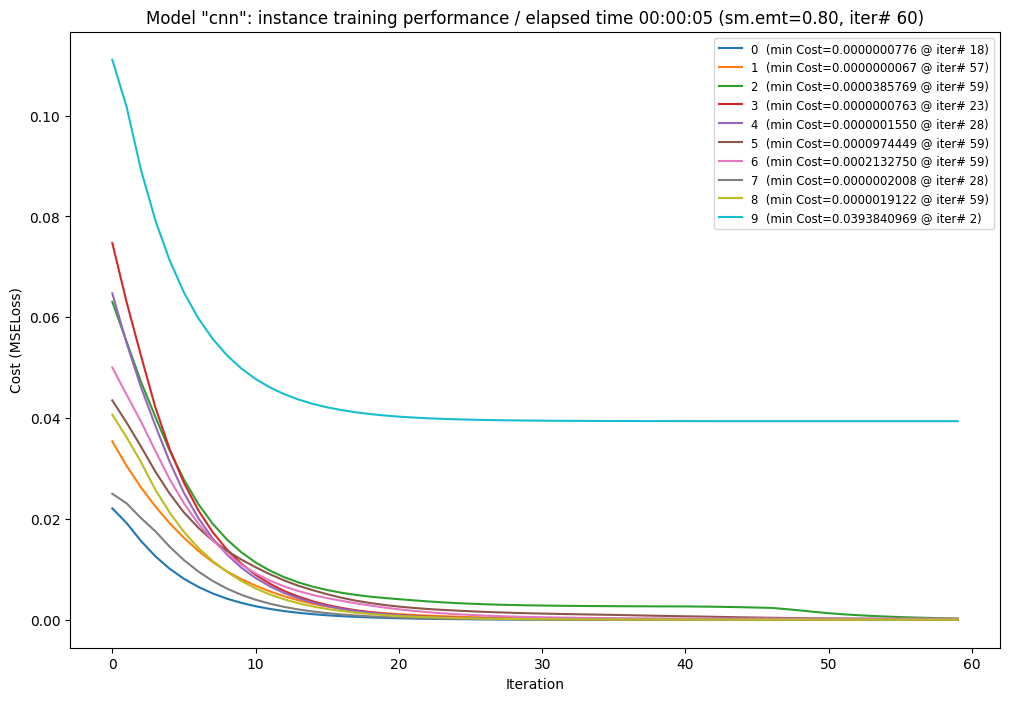

In [22]:
### Plot all trained instances
lin_plot_path = f'{FIGURES_PATH}/{TRAIN_PREF}/train_perform_vs_iter_lin_'+'_'.join(f'{x:02d}' for x in inst_list)+'.eps'
multi_perform_plot(objfun_vals_list, log_interv=log_interval, smooth_weight=0.8, prec=10,
    rcParams=(12, 8), dpi=100, meas_type=f'Cost', ylabel=f'Cost ({loss_name})', # xlim=(-0.5, 20), # yscale='log',
    title=f'Model "{CASE_NAME}": instance training performance / elapsed time {time_str}', 
    opt_format='0.10f', save_plot=lin_plot_path
    )

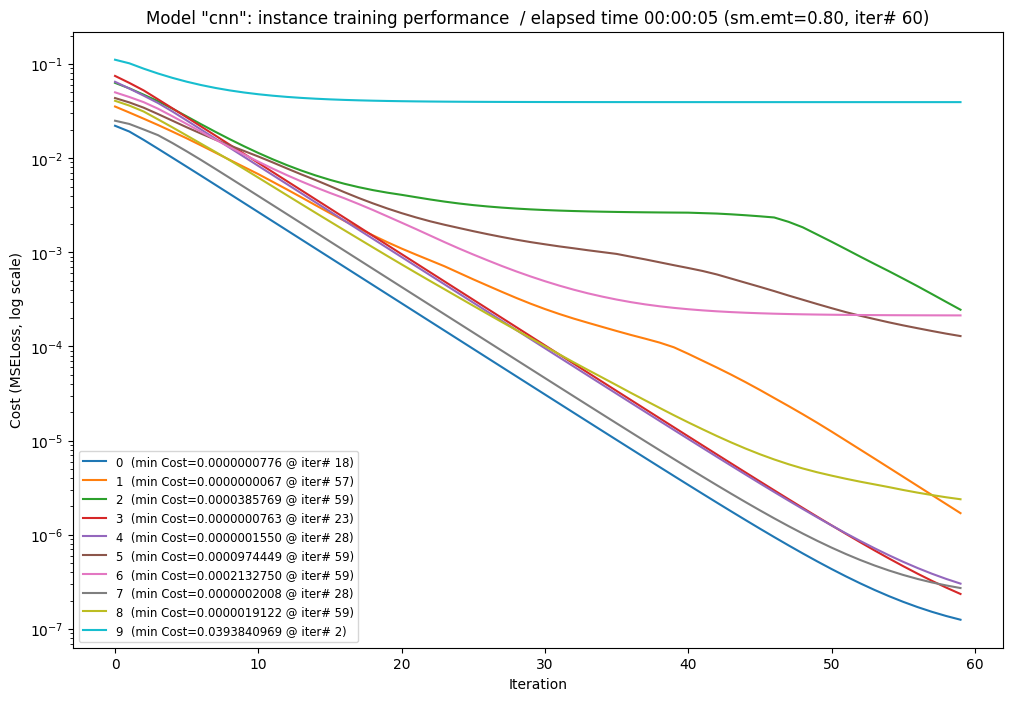

In [23]:
### Plot all trained instances
log_plot_path = f'{FIGURES_PATH}/{TRAIN_PREF}/train_perform_vs_iter_log_'+'_'.join(f'{x:02d}' for x in inst_list)+'.eps'
multi_perform_plot(objfun_vals_list, log_interv=log_interval, smooth_weight=0.8, prec=10, 
                   rcParams=(12, 8), dpi=100, yscale='log', ylabel=f'Cost ({loss_name}, log scale)',
                   title=f'Model "{CASE_NAME}": instance training performance  / elapsed time {time_str}', 
                   opt_format='0.10f', save_plot=log_plot_path
                   )

## System

In [24]:
import sys
print(f'\nEnvironment:\n\n{sys.prefix}\n')


Environment:

/home/jacob/miniconda3/envs/qiskit-gpu



In [25]:
import os
print(f"\nSignificant packages:\n")
os.system('pip list | grep -e qiskit -e torch');


Significant packages:

qiskit                        1.2.4
qiskit-aer-gpu                0.15.1
qiskit-algorithms             0.3.1
qiskit-ibm-runtime            0.32.0
qiskit-machine-learning       0.8.1
qiskit-optimization           0.6.1
qiskit-sphinx-theme           1.16.1
torch                         2.6.0
torchaudio                    2.6.0
torchsummary                  1.5.1
torchvision                   0.21.0
